In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import joblib

In [9]:
df = pd.read_csv("../dataset/Maternal Health Risk Data Set.csv")

In [10]:
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   str    
dtypes: float64(2), int64(4), str(1)
memory usage: 63.8 KB


In [12]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [13]:
df.isnull().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(562)

EDA

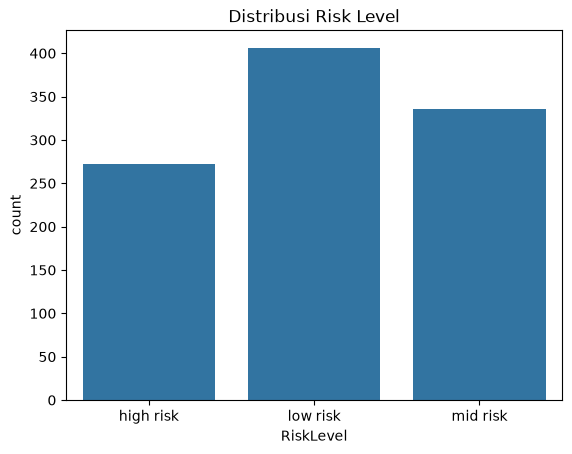

In [15]:
sns.countplot(
    x='RiskLevel',
    data=df
)

plt.title("Distribusi Risk Level")
plt.show()

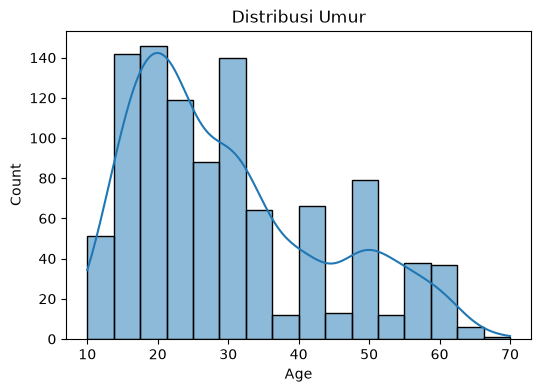

In [16]:
plt.figure(figsize=(6,4))

sns.histplot(
    df['Age'],
    kde=True
)

plt.title("Distribusi Umur")
plt.show()

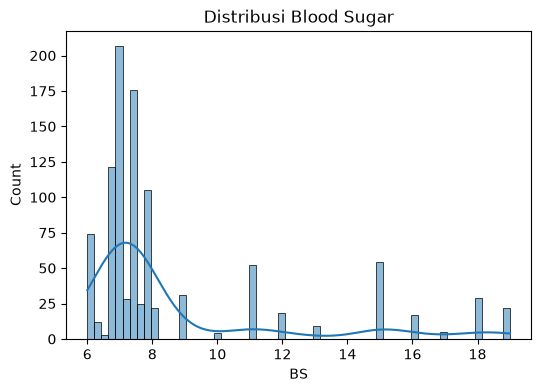

In [17]:
plt.figure(figsize=(6,4))

sns.histplot(
    df['BS'],
    kde=True
)

plt.title("Distribusi Blood Sugar")
plt.show()

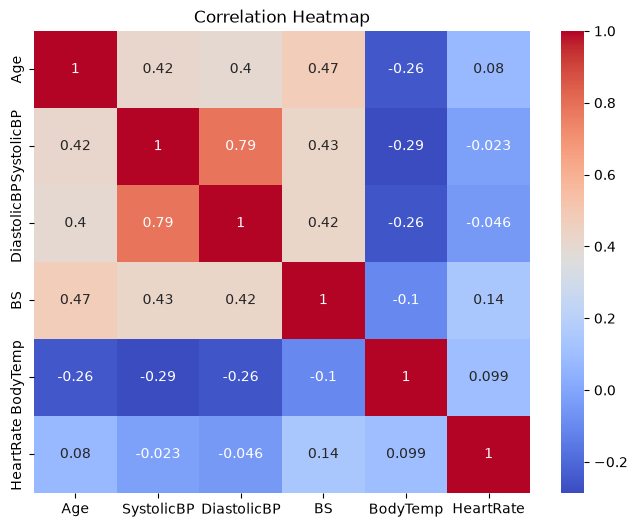

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop("RiskLevel",axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

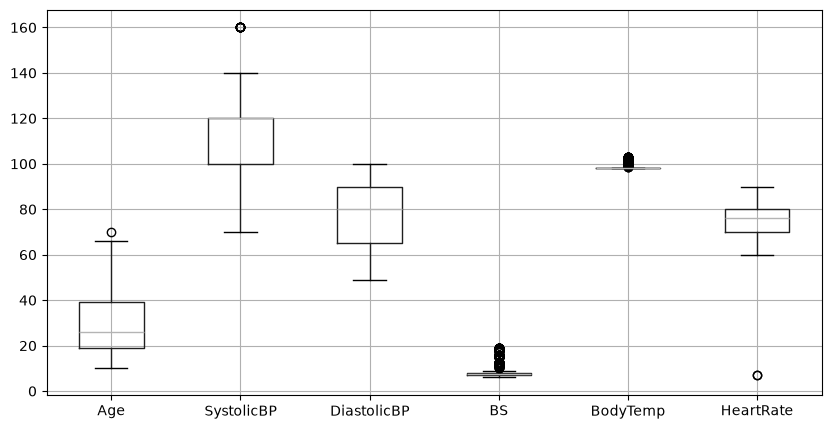

In [19]:
df.boxplot(
    figsize=(10,5)
)

plt.show()

In [20]:
encoder = LabelEncoder()

df["RiskLevel"] = encoder.fit_transform(
    df["RiskLevel"]
)

In [21]:
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,0
1,35,140,90,13.0,98.0,70,0
2,29,90,70,8.0,100.0,80,0
3,30,140,85,7.0,98.0,70,0
4,35,120,60,6.1,98.0,76,1


In [22]:
X = df.drop(
    "RiskLevel",
    axis=1
)

y = df["RiskLevel"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
print(X_train.shape)
print(X_test.shape)

(811, 6)
(203, 6)


In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

Decision Tree

In [26]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train_scaled,
    y_train
)

pred_dt = dt.predict(
    X_test_scaled
)

acc_dt = accuracy_score(
    y_test,
    pred_dt
)

print(acc_dt)

0.8374384236453202


Random Forest

In [27]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train_scaled,
    y_train
)

pred_rf = rf.predict(
    X_test_scaled
)

acc_rf = accuracy_score(
    y_test,
    pred_rf
)

print(acc_rf)

0.8620689655172413


KNN

In [28]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train_scaled,
    y_train
)

pred_knn = knn.predict(
    X_test_scaled
)

acc_knn = accuracy_score(
    y_test,
    pred_knn
)

print(acc_knn)

0.6699507389162561


Bandingkan Model

In [29]:
results = pd.DataFrame({
    "Model":[
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "Accuracy":[
        acc_dt,
        acc_rf,
        acc_knn
    ]
})

results

,Model,Accuracy
0,Decision Tree,0.837438
1,Random Forest,0.862069
2,KNN,0.669951


In [30]:
print(
    classification_report(
        y_test,
        pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.96      0.95      0.95        55
           1       0.89      0.80      0.84        81
           2       0.76      0.87      0.81        67

    accuracy                           0.86       203
   macro avg       0.87      0.87      0.87       203
weighted avg       0.87      0.86      0.86       203



Confusion Matrix

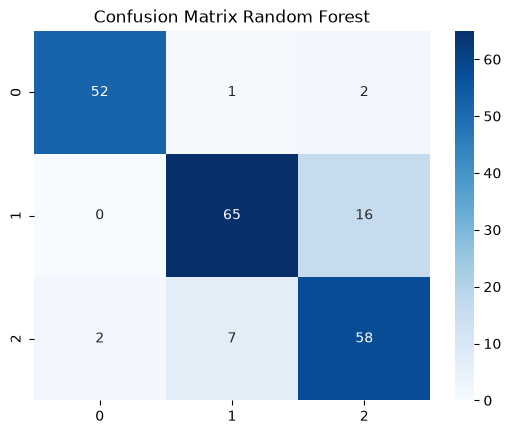

In [31]:
cm = confusion_matrix(
    y_test,
    pred_rf
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix Random Forest")
plt.show()

In [32]:
print(df["RiskLevel"].unique())

[0 1 2]


In [33]:
encoder.classes_

array(['high risk', 'low risk', 'mid risk'], dtype=object)

In [34]:
print(df.shape)

(1014, 7)


In [35]:
import os

os.makedirs(
    "models",
    exist_ok=True
)

In [36]:
import joblib

joblib.dump(
    rf,
    "models/model.pkl"
)

joblib.dump(
    scaler,
    "models/scaler.pkl"
)

['models/scaler.pkl']

In [37]:
print(type(rf))
print(type(scaler))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
<class 'sklearn.preprocessing._data.StandardScaler'>


In [38]:
from sklearn.model_selection import cross_val_score

In [39]:
cv_scores = cross_val_score(
    rf,
    X_train_scaled,
    y_train,
    cv=5
)

print("Cross Validation Scores:")
print(cv_scores)

print("Mean CV Accuracy:")
print(cv_scores.mean())

Cross Validation Scores:
[0.80981595 0.83333333 0.84567901 0.79012346 0.83950617]
Mean CV Accuracy:
0.8236915852457776


In [40]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

       Feature  Importance
3           BS    0.351597
1   SystolicBP    0.192600
0          Age    0.158901
2  DiastolicBP    0.127001
5    HeartRate    0.102978
4     BodyTemp    0.066923


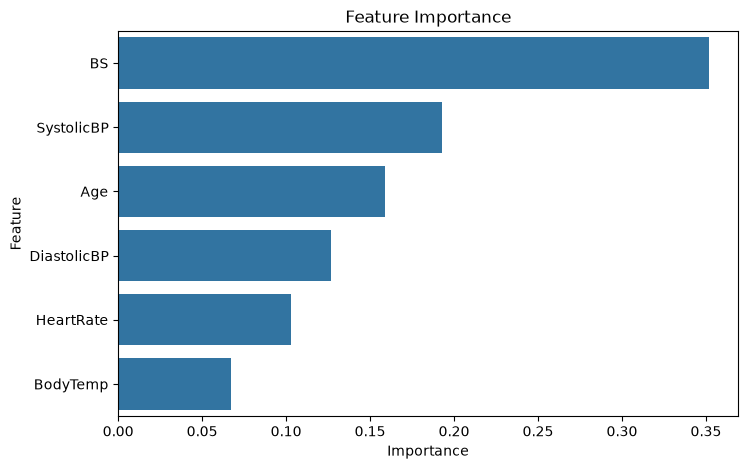

In [41]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [42]:
train_acc = rf.score(
    X_train_scaled,
    y_train
)

test_acc = rf.score(
    X_test_scaled,
    y_test
)

print("Training Accuracy:",train_acc)
print("Testing Accuracy:",test_acc)

Training Accuracy: 0.9247842170160296
Testing Accuracy: 0.8620689655172413
